In [47]:
# MVP Hello World: Coleta simples e modelo mínimo
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import shutil
    

In [48]:
# Desabilita a GPU para o TensorFlow não tentar usá-la e falhar
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [49]:
TICKER = 'AAPL'  # Ou 'PETR4.SA' para Petrobras
START = '2018-01-01'
END = '2024-12-31'

In [50]:
def fetch_data(symbol=TICKER, start=START, end=END):
    """Coleta dados brutos."""
    df = yf.download(symbol, start=start, end=end)
    return df

def scaling_data(data):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    return scaled_data, scaler

def create_sequences(data, window=60):
    """Cria janelas deslizantes para LSTM."""
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

def preprocess_pipeline(df, window=60):
    scaled_data, scaler = scaling_data(df)    
    X, y = create_sequences(scaled_data, window=window)

    
    # Split treino/teste (80/20)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    return X_train, y_train, X_test, y_test, scaler

def build_model(input_shape):
    model = Sequential()
    # Camada LSTM com retorno de sequência (para empilhar outra LSTM se quiser)
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2)) # Evita Overfitting
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=1)) # Saída: O preço previsto
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [51]:
print("Baixando dados...")
df = fetch_data(TICKER, START, END)
df.head(5)

/tmp/ipykernel_49913/3207751948.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Baixando dados...


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.341892,40.351262,39.639317,39.850091,102223600
2018-01-03,40.334866,40.878192,40.271636,40.405124,118071600
2018-01-04,40.522209,40.625254,40.299728,40.407454,89738400
2018-01-05,40.983574,41.070224,40.526901,40.618235,94640000
2018-01-08,40.831356,41.126437,40.732992,40.831356,82271200


In [52]:
df.shape

(1760, 5)

In [53]:
print("Pré-processamento")
close = df[['Close']]
X_train, y_train, X_test, y_test, scaler = preprocess_pipeline(close)

Pré-processamento


In [54]:
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

X_train: (1360, 60, 1)
y_train: (1360, 1)
X_test: (340, 60, 1)
y_test: (340, 1)


Treinando Modelo...


/home/isapt/docs/lstm-predict/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0146 - val_loss: 0.0036
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0020 - val_loss: 0.0014
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0020 - val_loss: 0.0026
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 7/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 8/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - val_loss: 0.0027
Epoch 9/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0016 - val_loss: 8.6670e-04
Epoch 10/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0017 - val_loss: 0.0027
Epoch 11/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0015 - val_loss: 0.0066
Epoch 12/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss:

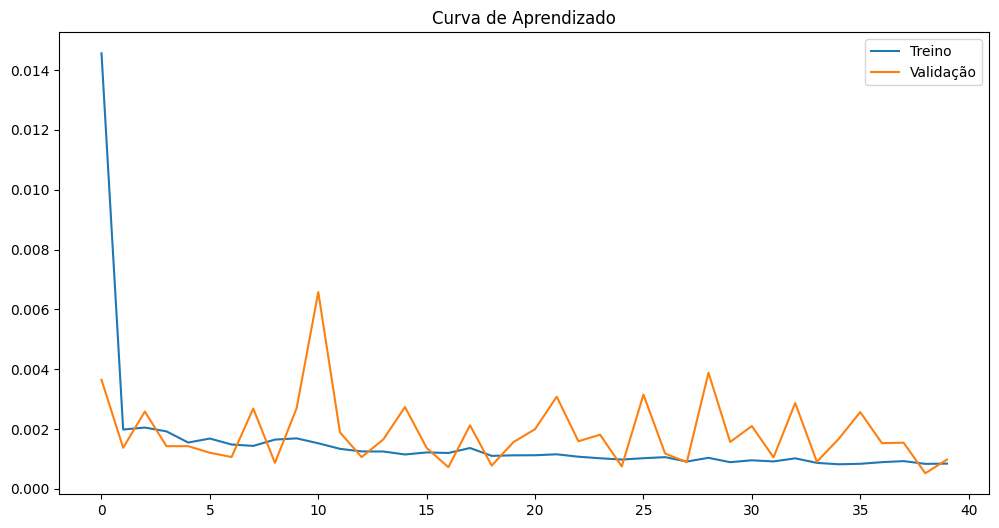

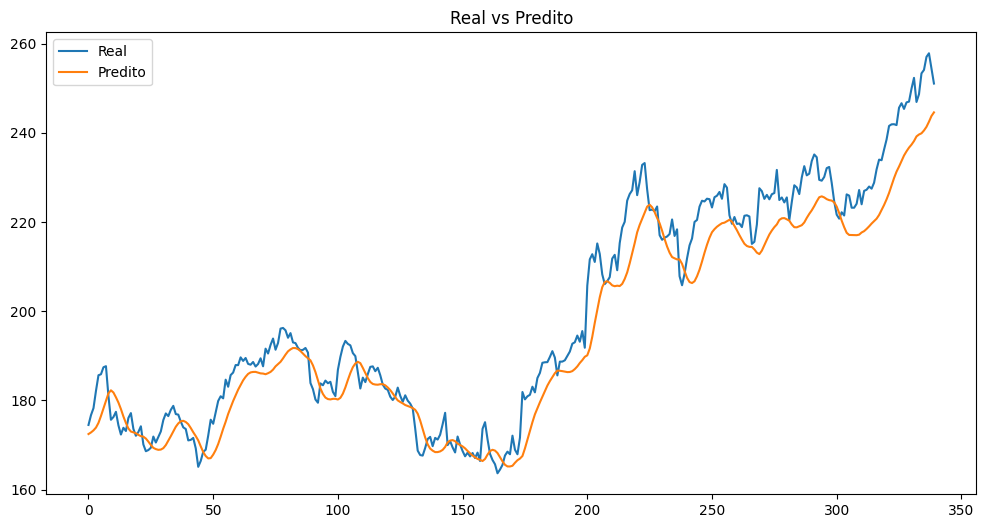

Processo finalizado com sucesso.


In [ ]:
# Configura o experimento 
epochs = 40
batch_size = 32


# 1. LOGUE PARÂMETROS PRIMEIRO (Segurança)
# Se o treino falhar, pelo menos você sabe qual configuração causou o erro.


print("Treinando Modelo...")
# Construção do modelo (assumindo que build_model, X_train, etc. já existem)
model = build_model((X_train.shape[1], 1))

history = model.fit(
    X_train, y_train, 
    epochs=epochs, 
    batch_size=batch_size, 
    verbose=1, 
    validation_data=(X_test, y_test)
)

# 2. SALVAR ARTEFATOS (MODELO E SCALER)
print("Salvando artefatos...")

# Define o caminho
local_model_dir = "../modelos"
os.makedirs(local_model_dir, exist_ok=True) # <--- O SEGREDO ESTÁ AQUI
    
# Salva localmente
model_path = f"{local_model_dir}/lstm_mvp.keras"
model.save(model_path)

scaler_path = f"{local_model_dir}/scaler.pkl"
joblib.dump(scaler, scaler_path)

# 3. AVALIAÇÃO E MÉTRICAS
print("Avaliando...")
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_inv = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_inv, predictions)
rmse = np.sqrt(mean_squared_error(y_test_inv, predictions))
# Correção para evitar divisão por zero no MAPE se houver valores 0
with np.errstate(divide='ignore', invalid='ignore'):
    mape = np.mean(np.abs((y_test_inv - predictions) / y_test_inv)) * 100
    if np.isnan(mape): mape = 0.0

metrics = {"mae": mae, "rmse": rmse, "mape": mape}

print(f"Métricas: {metrics}")

# 4. PLOTS (A ordem importa!)
print("Gerando gráficos...")

# -- Gráfico 1: Loss --
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Curva de Aprendizado')
plt.legend()
plt.show()

# -- Gráfico 2: Predição --
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label='Real')
plt.plot(predictions, label='Predito')
plt.title('Real vs Predito')
plt.legend() # O .legend() puxa os labels definidos no .plot acima
plt.show()

print("Processo finalizado com sucesso.")